# NETFLIX DATA ANALYSIS (CODE)

In [6]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [7]:
!unzip archive.zip

Archive:  archive.zip
  inflating: netflix_titles.csv      


In [8]:
import pandas as pd
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


##1. Data Loading and Basic Checking

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("netflix_titles.csv")

# Basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nData Types:\n", df.dtypes)

# First 10 rows
df.head(10)

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

Shape: (8807, 12)

Columns: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Data Types:
 show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


##2. Data Cleaning

In [11]:
# Fill missing values
df.fillna({
    'director': 'Unknown',
    'cast': 'Not Available',
    'country': 'Unknown',
    'rating': 'Not Rated'
}, inplace=True)

# Drop missing date
df.dropna(subset=['date_added'], inplace=True)

# Convert format
df['type'] = df['type'].str.lower()
df['rating'] = df['rating'].str.lower()
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', dayfirst=False)

print("Cleaning Done")

Cleaning Done


##3. Analysis

In [12]:
# Most common rating
print("Most Common Rating:\n", df['rating'].value_counts().head(1))

# Top 5 countries
top_countries = df['country'].value_counts().head(5)
print("\nTop Countries:\n", top_countries)

# Avg release year by type
print("\nAvg Year:\n", df.groupby('type')['release_year'].mean())

Most Common Rating:
 rating
tv-ma    3205
Name: count, dtype: int64

Top Countries:
 country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
Name: count, dtype: int64

Avg Year:
 type
movie      2013.121514
tv show    2016.625656
Name: release_year, dtype: float64


##4. Trend

In [13]:
# Year added
df['year_added'] = df['date_added'].dt.year

titles_per_year = df.groupby('year_added').size()
print("\nTitles per Year:\n", titles_per_year)


Titles per Year:
 year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
dtype: int64


##5. Visualizations

<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1053/1624579132.py:17: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


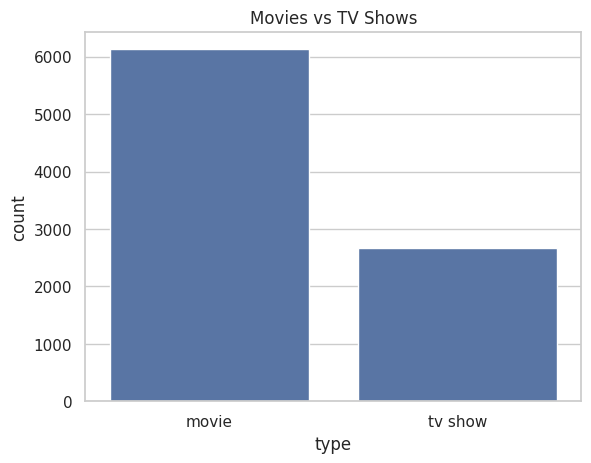

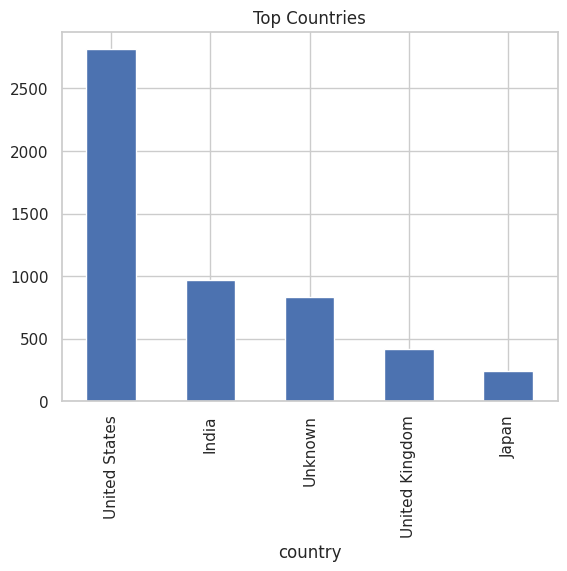

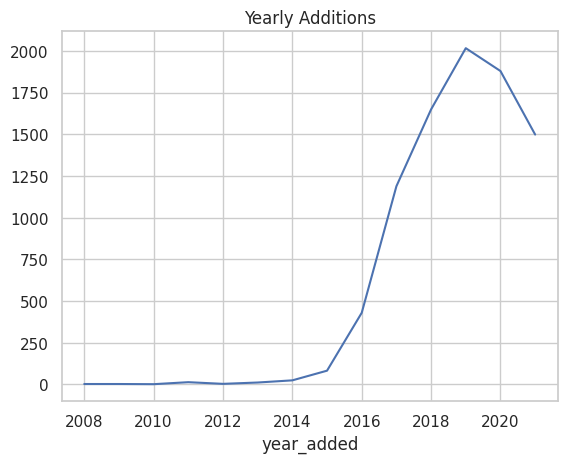

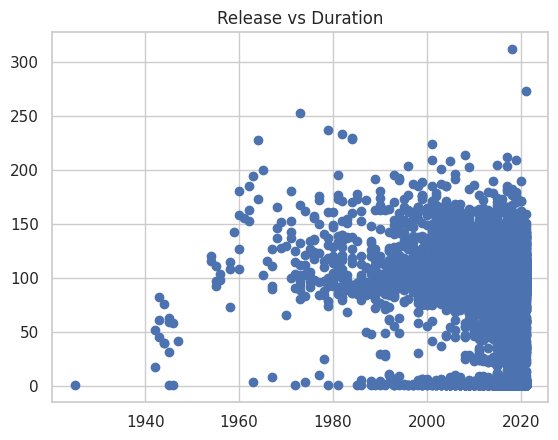

In [14]:
# Count plot
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

# Bar chart
top_countries.plot(kind='bar')
plt.title("Top Countries")
plt.show()

# Line chart
titles_per_year.plot()
plt.title("Yearly Additions")
plt.show()

# Scatter
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
plt.scatter(df['release_year'], df['duration_num'])
plt.title("Release vs Duration")
plt.show()

##6. Conclusion

- Movies are more than TV Shows
- Most content from top countries
- Rapid growth after 2015
- Popular rating dominates

Insight:
Netflix should focus on regional and diverse content.